# Olympics Analysis from 1896 to 2016
### Spring 2026 Data Science Project
**Name:** Michael Brown

**Github Repository:** [Olympics Analysis](https://github.com/Michael-1898/OlympicsAnalysis_CMSC320)

### Contributions
**Michael Brown** Sole contributor. Developed the project concept, performed data curation and preprocessing on the Olympic dataset, conducted exploratory data analysis, and performed a machine learning analysis.

---

## Introduction
TBD

---

### Library Imports
*The following libraries are used throughout this tutorial

In [66]:
# General
import pandas as pd
import numpy as np
import string

# EDA
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---

## Dataset Curation and Preprocessing
#### Dataset Breakdown
This section walks through the process of transforming a raw dataset into a clean, structured format ready for machine learning. This involves filtering out historical noise, handling missing values, and engineering new features that better capture the relationship between an athlete's physical profile and their success.

The primary dataset for this analysis is the 120 years of Olympic history: athletes and results, which can be found on Kaggle. This dataset contains 271,116 rows and 15 columns, tracking every athlete who participated in the Olympic Games from Athens 1896 to Rio 2016.

#### Loading the Data

In [43]:
# Load the datasets
olympics_df = pd.read_csv('athlete_events.csv')
noc_regions_df = pd.read_csv('noc_regions.csv')

# Merge with regions to have country names associated with National Olympic Committees (NOC)
olympics_df = pd.merge(olympics_df, noc_regions_df, on='NOC', how='left')

# Display the first few rows
olympics_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


#### Filtering to the Modern Era
One of the most important steps in this pipeline is narrowing the scope. Large amounts of physiological data for the early years of the Olympics (1896–1950s), like height and weight is missing. Furthermore, the level of professionalization and specialized training was different than it is today. Machine learning models are only as good as the data provided to them. So to ensure our model is accurate and relevant we filter the dataset to include only the years from 1965 onward.

In [44]:
# Filter for the modern era to ensure better data quality and relevance
modern_olympics = olympics_df[olympics_df['Year'] >= 1965].copy()

# Check for missing values in our key physical attributes
print(modern_olympics[['Height', 'Weight', 'Age']].isnull().sum())
print(f"Remaining rows: {modern_olympics.shape[0]}")

Height     9477
Weight    10068
Age         838
dtype: int64
Remaining rows: 190357


#### Handling Missing Data and Medal Column
As you can seen, even with filtering to the "modern era", some athletes still have missing physioligical data. Since our dataset is still so large we will remove rows where this information is unavailable, as it won't have too large of an impact overall. We also need to transform the Medal column into a binary target variable: Won_Medal. After this, the proportion of medalists should be much smaller than the proportion of non-medlaists.

In [45]:
# Drop rows where critical physical data is missing
modern_olympics.dropna(subset=['Height', 'Weight', 'Age'], inplace=True)

# Create a binary target variable: 1 if any medal was won, 0 otherwise
modern_olympics['Won_Medal'] = modern_olympics['Medal'].notnull().astype(int)

# Verify the class balance
print(modern_olympics['Won_Medal'].value_counts(normalize=True))

Won_Medal
0    0.857328
1    0.142672
Name: proportion, dtype: float64


#### Feature Engineering: Sport Clustering
There are over 60 different sports in the dataset. But many of these sports look for similar physical characterisitics. So we can group sports with similar physical demands into "clusters." This helps the model identify broader patterns (e.g., "Combat Sports" vs. "Endurance Sports").

We also create a combined sport/sex feature since the physical requirments can vary by sex, even within a sport (such as gymnastics).

In [46]:
# Define a mapping for sport categories
sport_map = {
    'Basketball': 'Team_Ball', 'Volleyball': 'Team_Ball', 'Football': 'Team_Ball',
    'Wrestling': 'Combat', 'Judo': 'Combat', 'Boxing': 'Combat',
    'Swimming': 'Water_Power', 'Water Polo': 'Water_Power',
    'Gymnastics': 'Aesthetic_Tech', 'Diving': 'Aesthetic_Tech',
    'Athletics': 'Track_Field', 'Weightlifting': 'Power_Strength'
}

# Apply the mapping and fill others as 'Other'
modern_olympics['Sport_Category'] = modern_olympics['Sport'].map(sport_map).fillna('Other')

# Create a combined 'Sport_Sex' feature to capture sex-based physical requirements
modern_olympics['Sport_Sex'] = modern_olympics['Sport_Category'] + "_" + modern_olympics['Sex']

#### Final Data Preparation
Lastly, we drop columns that won't be used in the model (like Name, ID, or specific Games) and convert categorical variables into a format the computer can process.

In [65]:
# Selecting columns for the final analysis
features = ['Age', 'Height', 'Weight']
target = 'Won_Medal'
group = 'Sport_Sex'

# Quick dataset overview
print("Total rows:", len(modern_olympics))
print("Number of Sport_Sex categories:",
      modern_olympics[group].nunique())

print("\nCategories:")
print(sorted(modern_olympics[group].unique()))

# X = modern_olympics[features]
# y = modern_olympics['Won_Medal']

# Convert categorical features into dummy variables
# X_final = pd.get_dummies(X, columns=['Sport_Sex'], drop_first=True)

# display(X.head())
# print(f"Final feature set shape: {X.shape}")

Total rows: 179335
Number of Sport_Sex categories: 14

Categories:
['Aesthetic_Tech_F', 'Aesthetic_Tech_M', 'Combat_F', 'Combat_M', 'Other_F', 'Other_M', 'Power_Strength_F', 'Power_Strength_M', 'Team_Ball_F', 'Team_Ball_M', 'Track_Field_F', 'Track_Field_M', 'Water_Power_F', 'Water_Power_M']


---

## Exploratory Data Analysis (EDA)
Before starting our machine learning analysis, we'll perform some exploratory data analysis to identify patterns and justify specific features we will use in our predictive modeling.

#### Summary Statistics
Note the class imbalance for the Won_Medal feature. We'll have to consider this when evaluating our future model as predicting "no medal" everytime would still yield a high performance

In [48]:
# Displaying basic summary statistics for physical traits
print("Summary Statistics for Modern Olympians (1960-2016):")
display(modern_olympics[['Age', 'Height', 'Weight']].describe())

# Checking the target variable distribution
medal_counts = modern_olympics['Won_Medal'].value_counts(normalize=True) * 100
print(f"\nMedal Distribution:\n{medal_counts.map('{:.2f}%'.format)}")

Summary Statistics for Modern Olympians (1960-2016):


,Age,Height,Weight
count,179335.000000,179335.000000,179335.000000
mean,25.052700,175.573257,70.774110
std,5.450449,10.714303,14.660213
min,11.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,80.000000
max,71.000000,226.000000,214.000000



Medal Distribution:
Won_Medal
0    85.73%
1    14.27%
Name: proportion, dtype: object


#### Hypothesis Test: Does Age Drive Success?
Here we use a Welch's t-test to to determine if age is a meaningful predictor of success. We specifically use a Welch's t-test because it does not assume equal variance, as there is a large imbalance between medal vs. no medal.

**Question:** Do medalists differ physically from non-medalists?

**Null Hypothesis:** There is no difference in the mean age between athletes who did and did not win a medal.

**Alternative Hypothesis:** There is a difference in the mean age between athletes who did and did not win a medal

**Signifigance Level:** 0.01

In [49]:
# Splitting the data into medalists and non-medalists
medalists = modern_olympics[modern_olympics['Won_Medal'] == 1]['Age']
non_medalists = modern_olympics[modern_olympics['Won_Medal'] == 0]['Age']

# Welch's t-test
t_stat, p_val = ttest_ind(medalists, non_medalists, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 14.9513904200285
P-value: 2.1477611608787705e-50


**Interpretation:** The extremely low p-value ($2.15 \times 10^{-50}$) allows us to reject the null hypothesis with high confidence, supporting the conclusion that there is a statistically significant difference in the mean age of medalists compared to non-medalists. This result confirms that age is a statistically relevant predictor and subsequently should be a feature in our machine learning model to help distinguish successful athletes.

#### Correlation Analysis
Next, we look at how strongly each physical trait correlates with winning a medal. A correlation heatmap helps to visualize whether any single attribute (such as being exceptionally tall) is a strong sign for Olympic success.

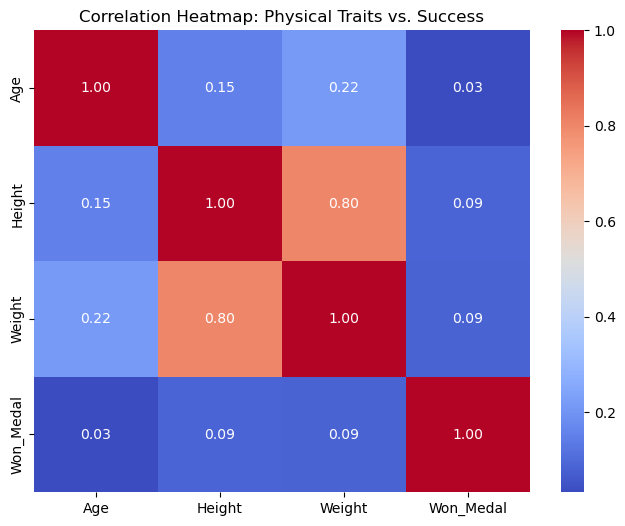

In [50]:
# Correlation matrix
corr_matrix = modern_olympics[['Age', 'Height', 'Weight', 'Won_Medal']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Physical Traits vs. Success')
plt.show()

**Interpretation:** The heatmap reveals very weak linear correlations between individual physical traits and winning a medal, with coefficients ranging from 0.03 for age to 0.09 for height and weight. These findings suggest that no single physical characteristic serves as a perfect predictor for Olympic success across all disciplines. Additionally, this lack of a linear signal justifies us using a more complex machine learning technique, such as a random forest, which can capture the non-linear interactions between these variables.

#### Visualization of Sport Context
The low global correlation found above occurs because the "ideal" body type changes drastically depending on the sport. To visualize this, we can look at the distribution of height across several distinct sport categories.

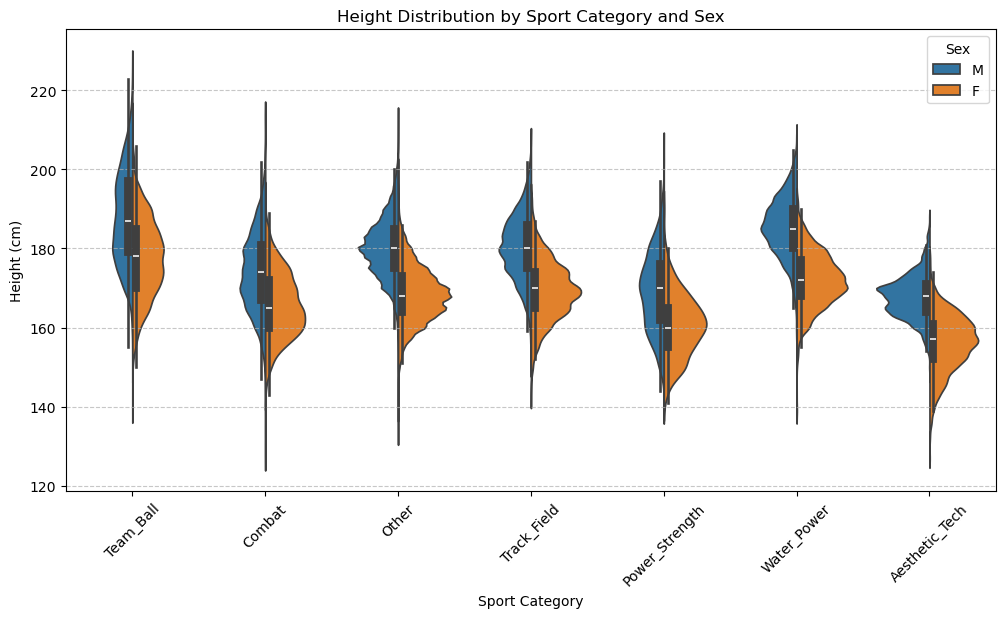

In [51]:
# Plot of height distributions by sport
plt.figure(figsize=(12, 6))
sns.violinplot(data=modern_olympics, x='Sport_Category', y='Height', hue='Sex', split=True)

plt.title('Height Distribution by Sport Category and Sex')
plt.xlabel('Sport Category')
plt.ylabel('Height (cm)')
plt.xticks(rotation=45)
plt.legend(title='Sex', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:** This visualization demonstrates that ideal physical archetypes are highly dependent on the specific sport. For example, athletes in Team_Ball are significantly taller on average than those in Aesthetic_Tech. Additionally, heigh differs not just by sport, but by sex within those sports. The distinct, non-overlapping distributions prove that physical data cannot be interpreted in a vacuum. This is exaclty why we added Sport_Sex as a feature in our model. It allows the algorithm to evaluate an athlete's height and weight within the context of their specific event.

---

## Primary Analysis
#### Machine Learning Model Design
Our goal is to predict the binary outcome of Won_Medal using an athlete's physical profile (Age, Height, Weight) and their context (Sport_Sex).

From our EDA, there are two notable things:
- Low linear correlation: individual physical traits have little linear relationship with winning
- High interaction dependency: The ideal physical traits vary depending on the sport and sex

These observations make a **Random Forest Classifier** a good fit for this problem as it can capture non-linear relationships, can handle relationships between categorical and numerical data, and is less prone to overfitting due to its ensemble architecture

We'll use **One-hot Encoding** to transform our categorical data into a numerical format so that the model can interpret it.

In [55]:
# Feature Selection
X = modern_olympics[['Age', 'Height', 'Weight', 'Sport_Sex']]
y = modern_olympics['Won_Medal']

# One-hot encoding
X_encoded = pd.get_dummies(X, columns=['Sport_Sex'], drop_first=True)

# Model initialization
rf_model = RandomForestClassifier(n_estimators=100, # 100 trees creates a nice diversity to reduce error without taking too long to compute
                                  class_weight='balanced', # Set class_weight to 'balanced' to account for the class imbalance in Won_Medal
                                  random_state=42)

#### Machine Learning Model Training
Now we split our dataset into a training set for the model to learn from and a testing set to test the model on afterwards to see how well it learned. we'll use a typical 80-20 split.

In [67]:
# Store trained models
models = {}

# Store evaluation results
results = []

# Store detailed reports
classification_reports = {}

# Minimum rows required for a category
MIN_ROWS = 100

# Loop through each Sport_Sex category
for category, df_cat in modern_olympics.groupby(group):

    print("=" * 60)
    print(f"Processing category: {category}")

    df_cat = df_cat.copy()

    # Skip very small datasets
    if len(df_cat) < MIN_ROWS:
        print(f"Skipped: fewer than {MIN_ROWS} rows")
        continue

    # Features and target
    X = df_cat[features]
    y = df_cat[target]

    # Skip if only one class exists
    if y.nunique() < 2:
        print("Skipped: only one class present")
        continue

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Create model
    model = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = (y_pred == y_test).mean()

    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan

    # Save results
    results.append({
        'Sport_Sex': category,
        'Rows': len(df_cat),
        'Medal_Rate': y.mean(),
        'Accuracy': accuracy,
        'ROC_AUC': auc
    })

    # Save model
    models[category] = model

    # Save classification report
    classification_reports[category] = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    print(f"Rows: {len(df_cat)}")
    print(f"Medal rate: {y.mean():.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"ROC-AUC: {auc:.3f}")

Processing category: Aesthetic_Tech_F
Rows: 6857
Medal rate: 0.079
Accuracy: 0.837
ROC-AUC: 0.700
Processing category: Aesthetic_Tech_M
Rows: 9160
Medal rate: 0.071
Accuracy: 0.829
ROC-AUC: 0.730
Processing category: Combat_F
Rows: 1359
Medal rate: 0.205
Accuracy: 0.750
ROC-AUC: 0.505
Processing category: Combat_M
Rows: 10034
Medal rate: 0.160
Accuracy: 0.754
ROC-AUC: 0.532
Processing category: Other_F
Rows: 31838
Medal rate: 0.169
Accuracy: 0.706
ROC-AUC: 0.579
Processing category: Other_M
Rows: 63126
Medal rate: 0.142
Accuracy: 0.725
ROC-AUC: 0.584
Processing category: Power_Strength_F
Rows: 460
Medal rate: 0.228
Accuracy: 0.717
ROC-AUC: 0.602
Processing category: Power_Strength_M
Rows: 2102
Medal rate: 0.157
Accuracy: 0.800
ROC-AUC: 0.518
Processing category: Team_Ball_F
Rows: 3618
Medal rate: 0.311
Accuracy: 0.610
ROC-AUC: 0.512
Processing category: Team_Ball_M
Rows: 6437
Medal rate: 0.242
Accuracy: 0.673
ROC-AUC: 0.574
Processing category: Track_Field_F
Rows: 9764
Medal rate: 0.10

In [68]:
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

print(results_df)
display(results_df)

           Sport_Sex   Rows  Medal_Rate  Accuracy   ROC_AUC
12     Water_Power_F   8368    0.148184  0.813620  0.767728
13     Water_Power_M  11215    0.141329  0.799822  0.750355
1   Aesthetic_Tech_M   9160    0.070633  0.828603  0.730387
0   Aesthetic_Tech_F   6857    0.079043  0.837464  0.700224
10     Track_Field_F   9764    0.102622  0.844854  0.612487
6   Power_Strength_F    460    0.228261  0.717391  0.602280
5            Other_M  63126    0.141954  0.725408  0.584082
4            Other_F  31838    0.169389  0.705716  0.579386
9        Team_Ball_M   6437    0.242038  0.673137  0.574082
11     Track_Field_M  14997    0.081083  0.848667  0.573913
3           Combat_M  10034    0.159558  0.754360  0.532406
7   Power_Strength_M   2102    0.157469  0.800475  0.517819
8        Team_Ball_F   3618    0.311222  0.610497  0.511917
2           Combat_F   1359    0.205298  0.750000  0.505084


,Sport_Sex,Rows,Medal_Rate,Accuracy,ROC_AUC
12,Water_Power_F,8368,0.148184,0.813620,0.767728
13,Water_Power_M,11215,0.141329,0.799822,0.750355
1,Aesthetic_Tech_M,9160,0.070633,0.828603,0.730387
0,Aesthetic_Tech_F,6857,0.079043,0.837464,0.700224
10,Track_Field_F,9764,0.102622,0.844854,0.612487
6,Power_Strength_F,460,0.228261,0.717391,0.602280
5,Other_M,63126,0.141954,0.725408,0.584082
4,Other_F,31838,0.169389,0.705716,0.579386
9,Team_Ball_M,6437,0.242038,0.673137,0.574082
11,Track_Field_M,14997,0.081083,0.848667,0.573913


In [56]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Training the model
rf_model.fit(X_train, y_train)

# Making predictions
y_pred = rf_model.predict(X_test)

# Performance analysis
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85     30828
           1       0.22      0.30      0.25      5039

    accuracy                           0.76     35867
   macro avg       0.55      0.56      0.55     35867
weighted avg       0.79      0.76      0.77     35867



#### Test Data Analysis
The F1-score of 0.25 shows that model is finding some patterns but is not able to learn enough to perform very well. This shows the difficulty of this problem, as there are a lot of other factors contributing to success in the Olympics (such as years training, experience, injuries, etc.).

The model achieved a **recall** of 0.30 for medalists. This means that even with looking at physical trait data alone, the algorithm successfully identified 30% of all medal winners.

The model acheived a **precision** of 0.22, meaning that when the model predicts an athlete will win a medal, they actually do about 22% of the time. This "false alarm" rate is an expected trade-off of setting class_weight to 'balanced'. This made the model more sensitive to potential winners to ensure we didn't miss them entirely.

However, the **weighted F1-Score** and overall **accuracy** of the model are still high because the model is still effective at identifying non-medalists, which is the majority class.

---

## Visualization and Result Analysis
Now that we have trained and tested our model, we can try to understand how it made its decisions. A Random Forest allows us to calculate feature importance, which quantifies how much each variable contributed to the model's ability to predict a medalist.

We will extract the top 10 most influential features. This will reveal whether raw physical traits (like Height and Weight) or specific sport contexts (like being a Male Weightlifter) are the primary drivers of success.

In [69]:
feature_importance_rows = []

for category, model in models.items():
    importances = model.feature_importances_

    for feature, importance in zip(features, importances):
        feature_importance_rows.append({
            'Sport_Sex': category,
            'Feature': feature,
            'Importance': importance
        })

importance_df = pd.DataFrame(feature_importance_rows)
display(importance_df.head())

,Sport_Sex,Feature,Importance
0,Aesthetic_Tech_F,Age,0.256176
1,Aesthetic_Tech_F,Height,0.375730
2,Aesthetic_Tech_F,Weight,0.368094
3,Aesthetic_Tech_M,Age,0.288489
4,Aesthetic_Tech_M,Height,0.335311


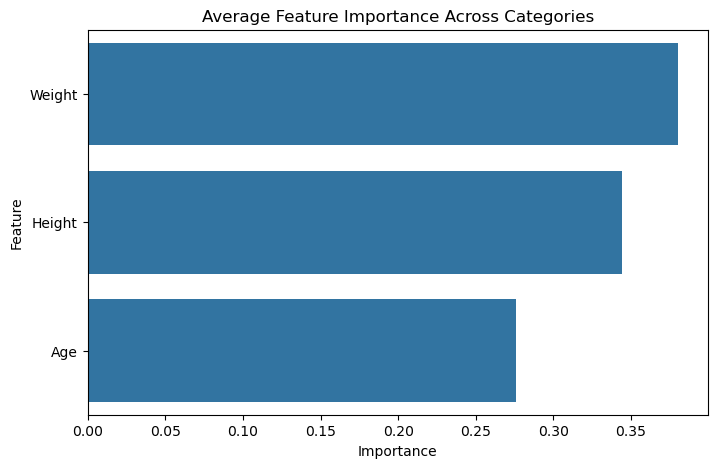

In [70]:
# Average feature importance across categories
avg_importance = (
    importance_df
    .groupby('Feature')['Importance']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_importance.values,
    y=avg_importance.index
)

plt.title("Average Feature Importance Across Categories")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [71]:
for category, report in classification_reports.items():
    print("=" * 60)
    print(category)

    report_df = pd.DataFrame(report).transpose()
    display(report_df)

Aesthetic_Tech_F


,precision,recall,f1-score,support
0,0.945252,0.874209,0.908344,1264.000000
1,0.216749,0.407407,0.282958,108.000000
accuracy,0.837464,0.837464,0.837464,0.837464
macro avg,0.581001,0.640808,0.595651,1372.000000
weighted avg,0.887907,0.837464,0.859115,1372.000000


Aesthetic_Tech_M


,precision,recall,f1-score,support
0,0.955410,0.855549,0.902726,1703.000000
1,0.198697,0.472868,0.279817,129.000000
accuracy,0.828603,0.828603,0.828603,0.828603
macro avg,0.577053,0.664209,0.591271,1832.000000
weighted avg,0.902126,0.828603,0.858864,1832.000000


Combat_F


...

,precision,recall,f1-score,support
0,0.928864,0.904606,0.916575,2757.000000
1,0.165079,0.213992,0.186380,243.000000
accuracy,0.848667,0.848667,0.848667,0.848667
macro avg,0.546972,0.559299,0.551477,3000.000000
weighted avg,0.866997,0.848667,0.857429,3000.000000


Water_Power_F


,precision,recall,f1-score,support
0,0.911982,0.864656,0.887689,1426.00000
1,0.400621,0.520161,0.452632,248.00000
accuracy,0.813620,0.813620,0.813620,0.81362
macro avg,0.656302,0.692409,0.670160,1674.00000
weighted avg,0.836225,0.813620,0.823236,1674.00000


Water_Power_M


,precision,recall,f1-score,support
0,0.904658,0.857217,0.880299,1926.000000
1,0.342105,0.451104,0.389116,317.000000
accuracy,0.799822,0.799822,0.799822,0.799822
macro avg,0.623381,0.654161,0.634707,2243.000000
weighted avg,0.825153,0.799822,0.810880,2243.000000


In [72]:
def predict_medal_probabilities(age, height, weight):
    athlete_df = pd.DataFrame([{
        'Age': age,
        'Height': height,
        'Weight': weight
    }])

    probabilities = {}
    for category, model in models.items():
        prob = model.predict_proba(athlete_df)[0][1]
        probabilities[category] = prob

    prob_df = pd.DataFrame({
        'Sport_Sex': probabilities.keys(),
        'Medal_Probability': probabilities.values()
    })

    prob_df = prob_df.sort_values(
        by='Medal_Probability',
        ascending=False
    )

    return prob_df

In [73]:
example_prediction = predict_medal_probabilities(
    age=24,
    height=190,
    weight=85
)

display(example_prediction.head(10))

,Sport_Sex,Medal_Probability
5,Other_M,0.686775
6,Power_Strength_F,0.350000
10,Track_Field_F,0.200000
2,Combat_F,0.190000
12,Water_Power_F,0.128518
8,Team_Ball_F,0.085959
4,Other_F,0.060000
9,Team_Ball_M,0.040000
3,Combat_M,0.038538
7,Power_Strength_M,0.030000


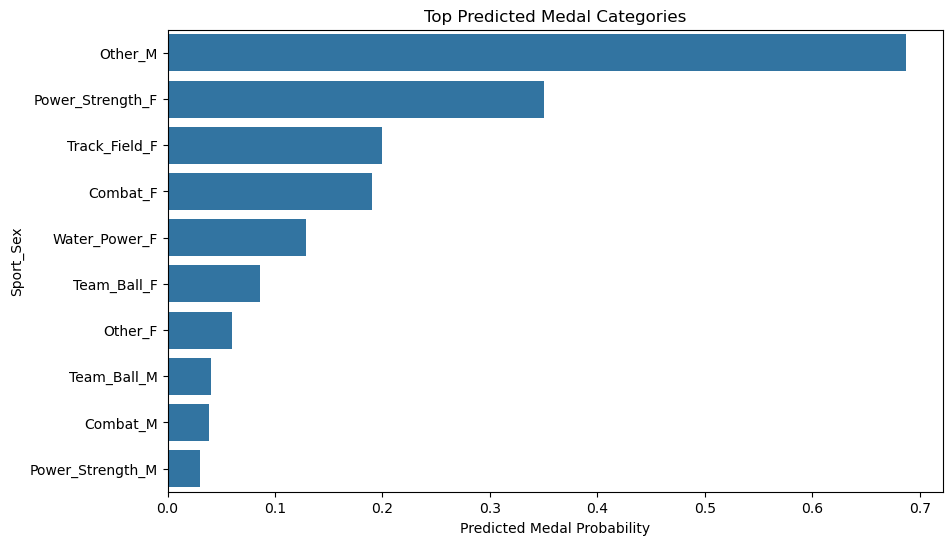

In [74]:
top_n = 10

top_predictions = example_prediction.head(top_n)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_predictions,
    x='Medal_Probability',
    y='Sport_Sex'
)

plt.title("Top Predicted Medal Categories")
plt.xlabel("Predicted Medal Probability")
plt.ylabel("Sport_Sex")
plt.show()

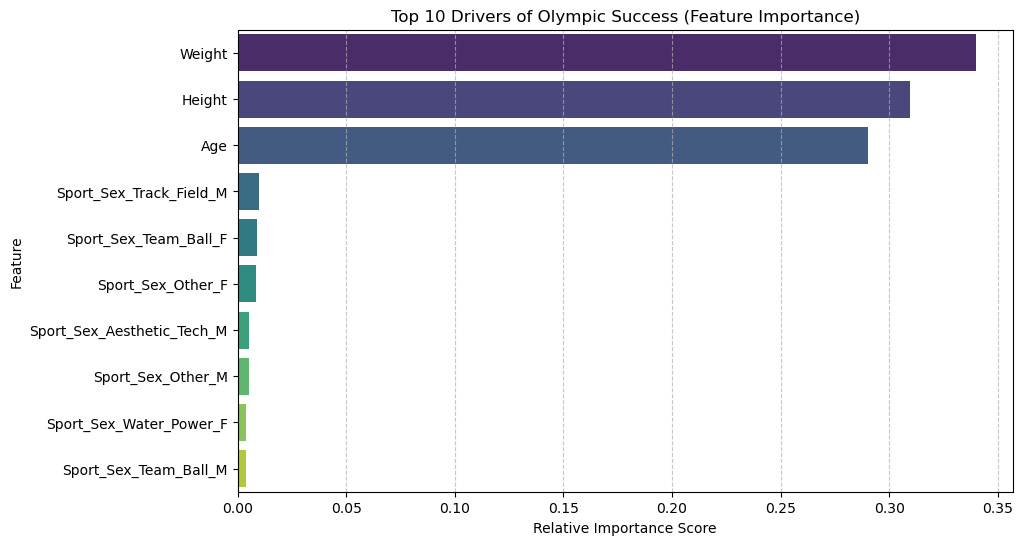

In [61]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort and take the top 10
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', hue='Feature', palette='viridis')

plt.title('Top 10 Drivers of Olympic Success (Feature Importance)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

We'll also create a confusion matrix to see where the model succeeded and failed.

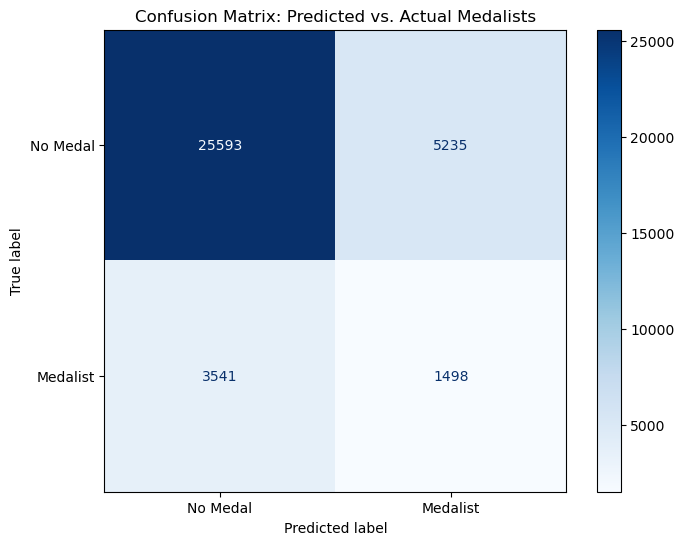

In [59]:
# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Medal', 'Medalist'])

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs. Actual Medalists')
plt.show()